# Data Visualization
**ShipmentSure — Predicting On-Time Delivery**

Comprehensive visual analysis of the ShipmentSure dataset:
- Count plots with and without hue
- Boxplots for continuous feature behavior
- Side-by-side comparison subplots for faster insight review

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('../data/Train.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Flight,2,5,306,6,high,M,45,3838,1
1,2,F,Ship,7,2,114,3,high,M,35,2710,1
2,3,B,Ship,7,2,215,7,medium,F,44,4152,0
3,4,A,Road,5,3,126,5,medium,M,54,2245,0
4,5,F,Ship,3,5,113,3,medium,M,43,1806,1


C:\Users\rishi\AppData\Local\Temp\ipykernel_13660\2279070569.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='Set2')
C:\Users\rishi\AppData\Local\Temp\ipykernel_13660\2279070569.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='Set2')
C:\Users\rishi\AppData\Local\Temp\ipykernel_13660\2279070569.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='Set2')
C:\Users\rishi\AppData\Local\Temp\ipykernel_13660\2279070569.py:8: Fut

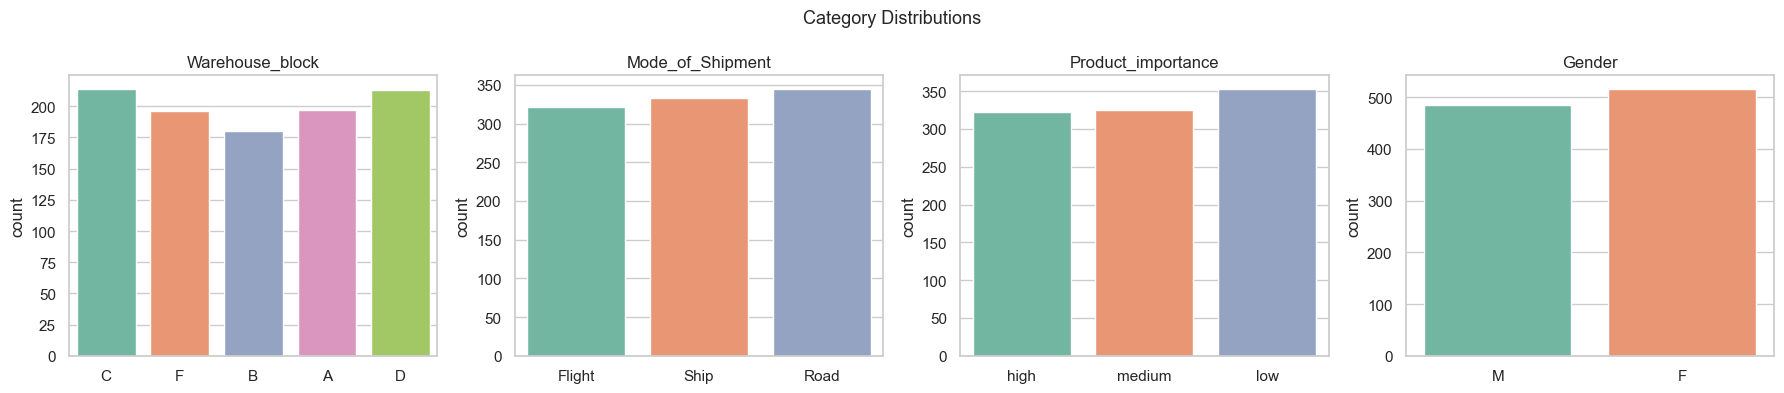

In [3]:
# Count plots — category distributions
cat_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Category Distributions', fontsize=13)

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

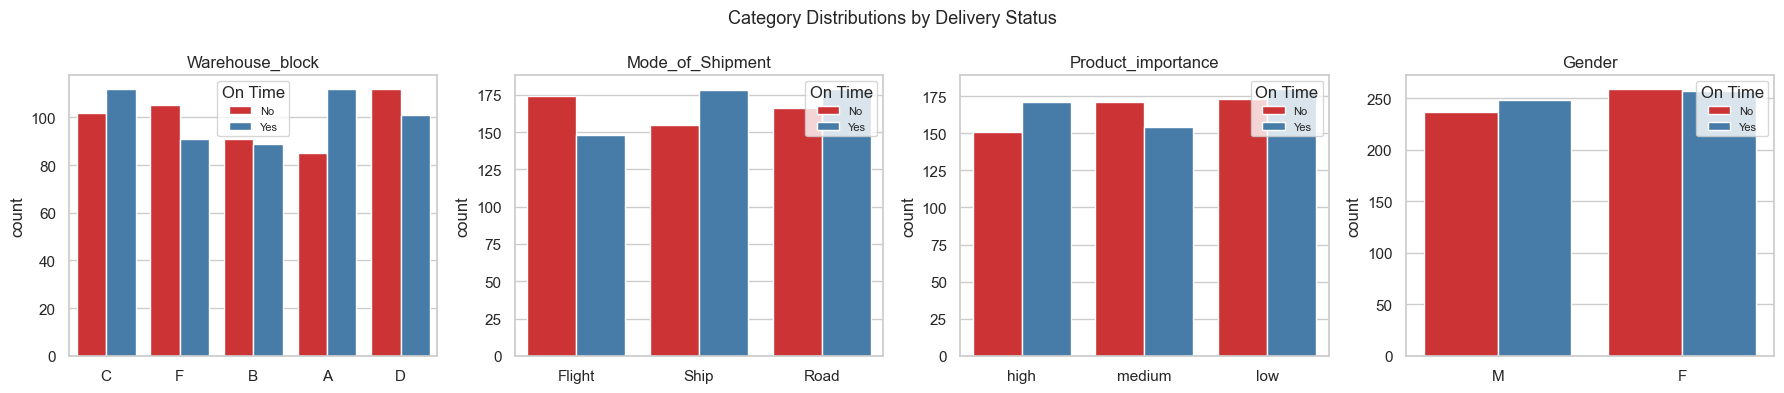

In [4]:
# Count plots WITH hue (by delivery status)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Category Distributions by Delivery Status', fontsize=13)

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Reached.on.Time_Y.N', data=df, ax=axes[i], palette='Set1')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(title='On Time', labels=['No', 'Yes'], fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\rishi\AppData\Local\Temp\ipykernel_13660\981853615.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Reached.on.Time_Y.N', y=col, ax=ax, palette='Set2')
C:\Users\rishi\AppData\Local\Temp\ipykernel_13660\981853615.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Reached.on.Time_Y.N', y=col, ax=ax, palette='Set2')
C:\Users\rishi\AppData\Local\Temp\ipykernel_13660\981853615.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Reached.on.Time_Y.N', y=col, ax=ax, palette='Set2')
C:\Users\rishi\A

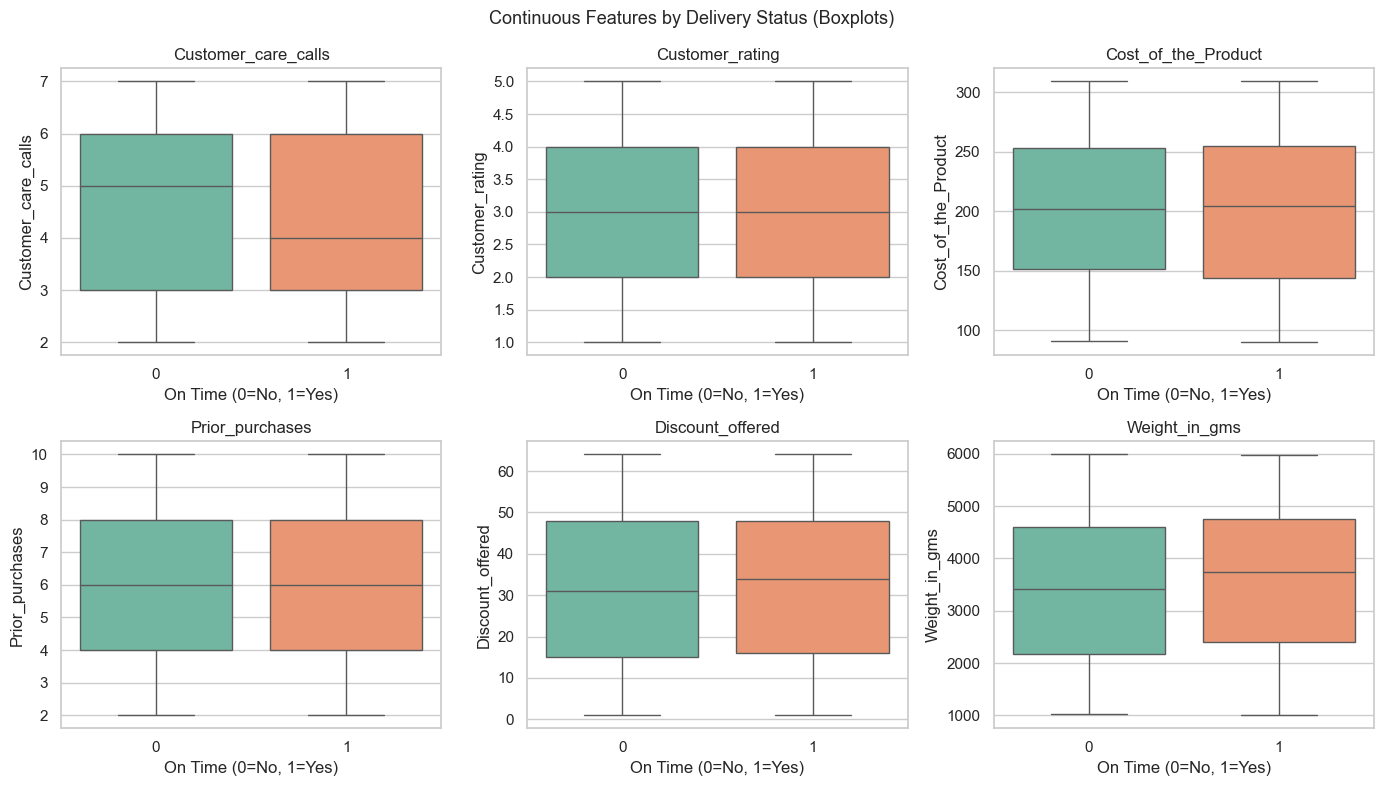

In [5]:
# Boxplots — continuous features by delivery status
num_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
            'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Continuous Features by Delivery Status (Boxplots)', fontsize=13)

for idx, col in enumerate(num_cols):
    ax = axes[idx // 3][idx % 3]
    sns.boxplot(data=df, x='Reached.on.Time_Y.N', y=col, ax=ax, palette='Set2')
    ax.set_title(col)
    ax.set_xlabel('On Time (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

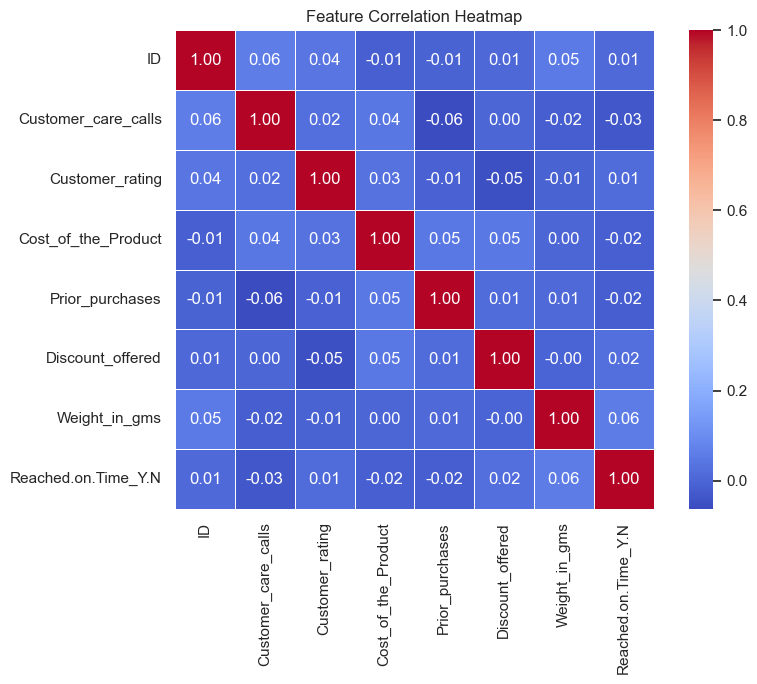

In [6]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

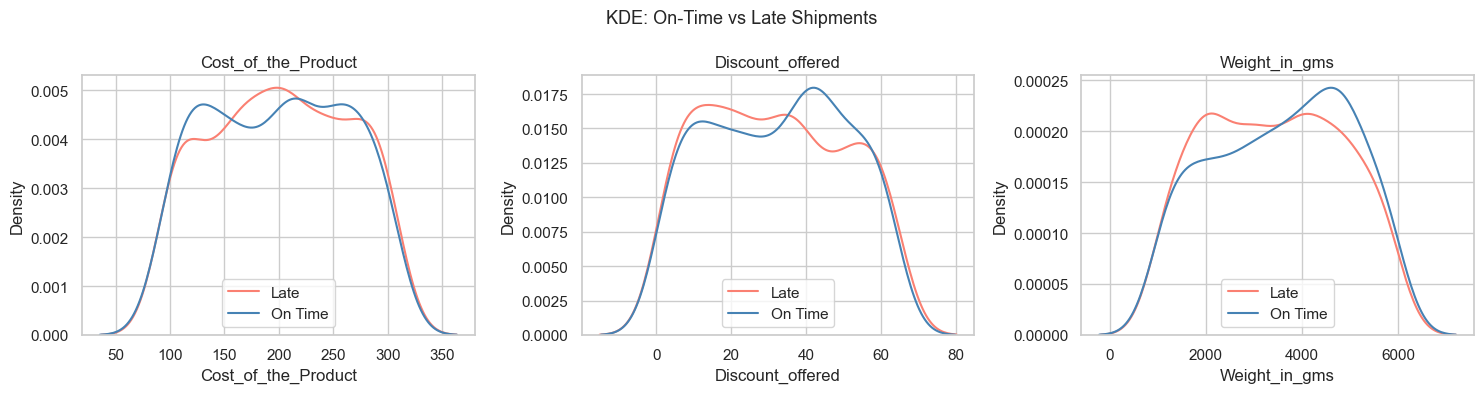

In [7]:
# KDE plots for key numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('KDE: On-Time vs Late Shipments', fontsize=13)

key_cols = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']
for i, col in enumerate(key_cols):
    for val, label, color in [(0, 'Late', 'salmon'), (1, 'On Time', 'steelblue')]:
        subset = df[df['Reached.on.Time_Y.N'] == val][col]
        sns.kdeplot(subset, ax=axes[i], label=label, color=color)
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

C:\Users\rishi\AppData\Local\Temp\ipykernel_13660\2573705731.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wh_rate.index, y=wh_rate.values, palette='Blues_d')


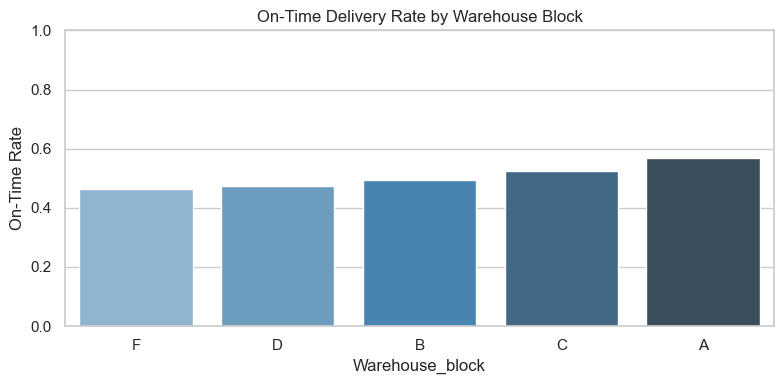

In [8]:
# Bar chart: On-time delivery rate by warehouse block
plt.figure(figsize=(8, 4))
wh_rate = df.groupby('Warehouse_block')['Reached.on.Time_Y.N'].mean().sort_values()
sns.barplot(x=wh_rate.index, y=wh_rate.values, palette='Blues_d')
plt.title('On-Time Delivery Rate by Warehouse Block')
plt.ylabel('On-Time Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()